# Modèle KNN — Classification de la densité urbaine
**Mini-projet 3 – Classification GeoAI (Issa Zouak)**

Ce notebook implémente le modèle K‑Nearest Neighbors (KNN) pour classer les zones urbaines selon leur densité. Les étapes incluent le chargement des données prétraitées, la préparation des variables, la recherche du meilleur nombre de voisins et de la métrique de distance, l’entraînement du modèle, l’évaluation et la validation croisée.

## 1. Importation des bibliothèques et configuration

In [1]:

# Import des librairies nécessaires
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

from IPython.display import Image, display
# Configuration générale
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Dossier pour enregistrer les figures
FIG_DIR = "knn_figures"
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42

print("Bibliothèques importées et configuration terminée.")


Bibliothèques importées et configuration terminée.


## 2. Chargement et préparation des données

Dimensions du dataset : (1411, 11)
Colonnes utilisées : ['densite_population', 'densite_batiments', 'hauteur_moy_bat', 'distance_centre_km', 'taux_impermeabilisation', 'wifi_density_probe']


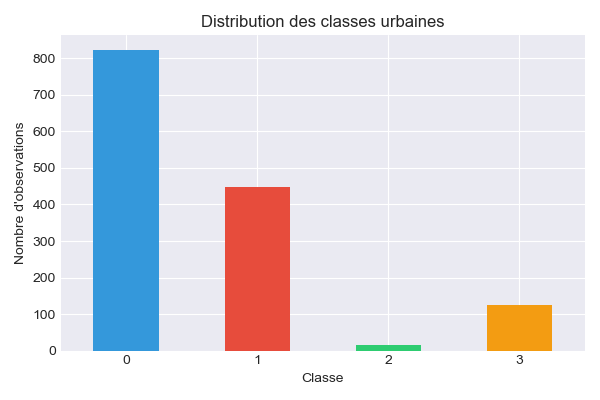

In [2]:

# Chargement du fichier prétraité
df = pd.read_csv('geo_urban_density_data_preprocessed.csv')

# Définition de la cible
y = df['target']

# Suppression des colonnes non utilisées
cols_to_drop = ['classe_urbaine', 'classe_urbaine_encoded', 'target', 'latitude', 'longitude']
X = df.drop(columns=cols_to_drop)

# Aperçu du dataset
print(f"Dimensions du dataset : {df.shape}")
print(f"Colonnes utilisées : {list(X.columns)}")

# Distribution des classes
plt.figure(figsize=(6, 4))
y.value_counts().sort_index().plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.title('Distribution des classes urbaines')
plt.xlabel('Classe')
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distribution_classes.png'))
plt.close()
display(Image(filename=os.path.join(FIG_DIR, 'distribution_classes.png'))) 


## 3. Séparation Train/Test

In [3]:

# Séparation avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Ensemble d'entraînement : {X_train.shape}, Ensemble de test : {X_test.shape}")


Ensemble d'entraînement : (1128, 6), Ensemble de test : (283, 6)


## 4. Recherche du meilleur nombre de voisins et de la métrique

,k,metric,accuracy,f1_macro
13,3,manhattan,0.872792,0.753946
15,5,manhattan,0.872792,0.748366
0,3,euclidean,0.851590,0.745822
17,7,manhattan,0.872792,0.724937
2,5,euclidean,0.833922,0.722925
1,4,euclidean,0.851590,0.720082
14,4,manhattan,0.851590,0.711804
4,7,euclidean,0.858657,0.617418
23,13,manhattan,0.869258,0.613909
20,10,manhattan,0.858657,0.607329


Meilleur k : 3, Meilleure métrique : manhattan


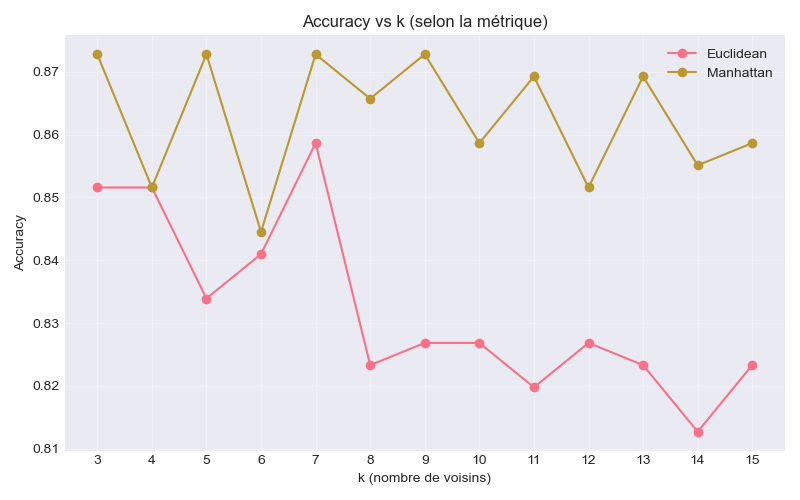

In [4]:

# Liste des k et des métriques à tester
k_values = list(range(3, 16))
metrics = ['euclidean', 'manhattan']

results = []

# Boucle sur les combinaisons de k et de métriques
for metric in metrics:
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        results.append({'k': k, 'metric': metric, 'accuracy': acc, 'f1_macro': f1})

# Conversion en DataFrame pour l'affichage
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='f1_macro', ascending=False)

# Affichage de la table triée
import IPython.display as ipd
ipd.display(results_df_sorted)

# Sélection du meilleur hyperparamètre
best_row = results_df.loc[results_df['f1_macro'].idxmax()]
best_k = int(best_row['k'])
best_metric = best_row['metric']
print(f"Meilleur k : {best_k}, Meilleure métrique : {best_metric}")

# Graphique Accuracy vs k
plt.figure(figsize=(8, 5))
for metric in metrics:
    subset = results_df[results_df['metric'] == metric]
    plt.plot(subset['k'], subset['accuracy'], marker='o', label=metric.capitalize())
plt.title('Accuracy vs k (selon la métrique)')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'accuracy_vs_k.png'))
plt.close()
display(Image(filename=os.path.join(FIG_DIR, "accuracy_vs_k.png")))


## 5. Entraînement et évaluation du modèle KNN final

Accuracy : 0.8728, F1-macro : 0.7539
Rapport de classification :
              precision    recall  f1-score   support

      Faible       0.94      0.88      0.91       165
     Moyenne       0.77      0.93      0.84        90
      Élevée       1.00      0.33      0.50         3
Industrielle       0.94      0.64      0.76        25

    accuracy                           0.87       283
   macro avg       0.91      0.70      0.75       283
weighted avg       0.88      0.87      0.87       283



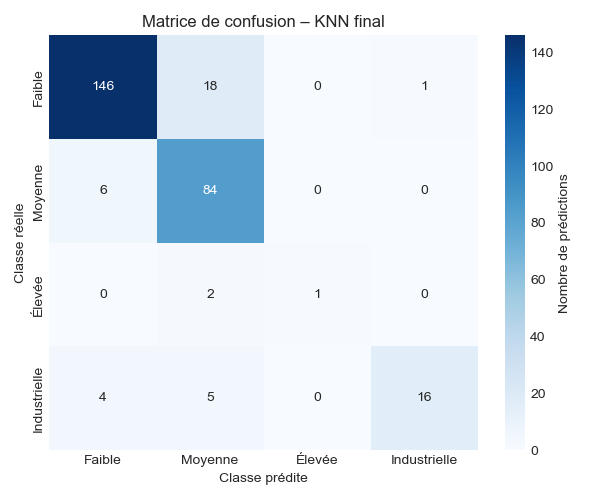

In [5]:

# Entraînement du modèle final
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_final.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred_final = knn_final.predict(X_test)

# Calcul des métriques
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average='macro')
print(f"Accuracy : {acc_final:.4f}, F1-macro : {f1_final:.4f}")

print("Rapport de classification :")
print(classification_report(y_test, y_pred_final, target_names=['Faible', 'Moyenne', 'Élevée', 'Industrielle']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faible', 'Moyenne', 'Élevée', 'Industrielle'],
            yticklabels=['Faible', 'Moyenne', 'Élevée', 'Industrielle'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title('Matrice de confusion – KNN final')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_knn.png'))
plt.close()
display(Image(filename=os.path.join(FIG_DIR, "confusion_matrix_knn.png")))


## 6. Validation croisée (5-fold)

Scores de validation croisée – Accuracy : [0.84070796 0.8539823  0.88053097 0.88       0.88      ]
Moyenne ± écart-type : 0.8670 ± 0.0166
Scores de validation croisée – F1-macro : [0.75828234 0.60450487 0.62270823 0.64234518 0.61861054]
Moyenne ± écart-type : 0.6493 ± 0.0558


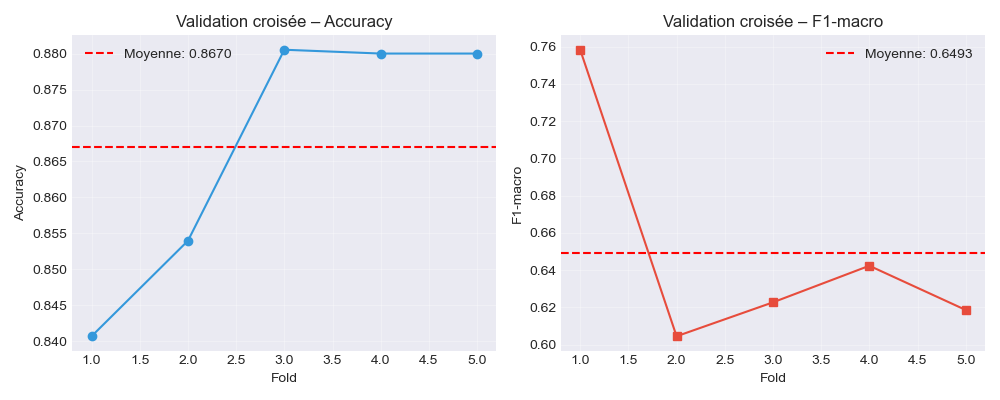

In [6]:

# Validation croisée pour évaluer la stabilité
cv_acc = cross_val_score(knn_final, X_train, y_train, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(knn_final, X_train, y_train, cv=5, scoring='f1_macro')

print("Scores de validation croisée – Accuracy :", cv_acc)
print(f"Moyenne ± écart-type : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print("Scores de validation croisée – F1-macro :", cv_f1)
print(f"Moyenne ± écart-type : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# Graphiques des scores
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 6), cv_acc, marker='o', color='#3498db')
plt.axhline(cv_acc.mean(), color='r', linestyle='--', label=f'Moyenne: {cv_acc.mean():.4f}')
plt.title('Validation croisée – Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), cv_f1, marker='s', color='#e74c3c')
plt.axhline(cv_f1.mean(), color='r', linestyle='--', label=f'Moyenne: {cv_f1.mean():.4f}')
plt.title('Validation croisée – F1-macro')
plt.xlabel('Fold')
plt.ylabel('F1-macro')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cross_validation_scores.png'))
plt.close()
display(Image(filename=os.path.join(FIG_DIR, "cross_validation_scores.png")))


## 7. Résumé et conclusion

In [7]:

print("Résumé des résultats :")
print(f"- Nombre de voisins optimal (k) : {best_k}")
print(f"- Métrique de distance optimale : {best_metric.capitalize()}")
print(f"- Accuracy (test) : {acc_final:.4f}")
print(f"- F1‑macro (test) : {f1_final:.4f}")
print(f"- Accuracy moyenne validation croisée : {cv_acc.mean():.4f}")
print(f"- F1‑macro moyenne validation croisée : {cv_f1.mean():.4f}")

print("Conclusion :")
print("Ce pipeline KNN montre qu’un nombre modéré de voisins et une distance", best_metric,
      "donnent de bonnes performances pour la classification de la densité urbaine.")
print("Le F1‑macro élevé indique un bon équilibre entre précision et rappel malgré un jeu de données limité.")
print("La validation croisée confirme la stabilité du modèle. Des explorations supplémentaires pourraient",
      "tester d’autres distances ou pondérations pour améliorer encore la robustesse.")


Résumé des résultats :
- Nombre de voisins optimal (k) : 3
- Métrique de distance optimale : Manhattan
- Accuracy (test) : 0.8728
- F1‑macro (test) : 0.7539
- Accuracy moyenne validation croisée : 0.8670
- F1‑macro moyenne validation croisée : 0.6493
Conclusion :
Ce pipeline KNN montre qu’un nombre modéré de voisins et une distance manhattan donnent de bonnes performances pour la classification de la densité urbaine.
Le F1‑macro élevé indique un bon équilibre entre précision et rappel malgré un jeu de données limité.
La validation croisée confirme la stabilité du modèle. Des explorations supplémentaires pourraient tester d’autres distances ou pondérations pour améliorer encore la robustesse.
